# Experience-Level Classification & Skill Analytics

**AI Project 2025/2026**

**Students:** Andrea Bardini and Filippo Maria Incecchi

**Professor:** Angela Locoro

Analytics and Data Science for Economics and Management

Università degli studi di Brescia

In [1]:
# ── 0. IMPORTS & CONFIG ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import time
from collections import Counter, defaultdict

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, LSTM,
                                     Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE = '/content/drive/MyDrive/AI Project 2025 2026 Bardini Incecchi/'

## Part 1 — Data Cleaning

We keep two parallel text fields per posting:
- `full_text` = title + description + skills_desc
- `desc_text` = description + skills_desc **only** (no title)

The title is excluded from `desc_text` so we can later measure how much of the model's accuracy comes from the title literally containing the label (the leakage experiment in Part 5).

In [2]:
# ── 1. LOAD DATASET ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(BASE + 'job_postings.csv', low_memory=False)
print(f"ORIGINAL: {df.shape[0]:,} rows x {df.shape[1]} columns "
      f"({df.memory_usage(deep=True).sum()/1e6:.1f} MB)")

# ── 2. KEEP RELEVANT COLUMNS ─────────────────────────────────
cols_to_keep = [
    'job_id', 'title', 'location', 'description', 'skills_desc',
    'pay_period', 'med_salary', 'formatted_work_type',
    'formatted_experience_level', 'currency'
]
df = df[cols_to_keep]

# ── 3. REMOVE DUPLICATES ─────────────────────────────────────
before = len(df)
df.drop_duplicates(subset='job_id', keep='first', inplace=True)
df.drop_duplicates(subset=['title', 'description', 'location'],
                   keep='first', inplace=True)
print(f"[DUPLICATES] Removed {before - len(df):,} rows.")

# ── 4. STANDARDIZE CATEGORICALS ──────────────────────────────
df['formatted_work_type']        = df['formatted_work_type'].str.strip().str.title()
df['formatted_experience_level'] = df['formatted_experience_level'].str.strip().str.title()
df['currency']                   = df['currency'].str.strip().str.upper()
df['pay_period']                 = df['pay_period'].str.strip().str.upper()

# ── 5. NORMALIZE SALARY TO YEARLY ────────────────────────────
multipliers = {'HOURLY': 2080, 'MONTHLY': 12, 'YEARLY': 1}
df['med_salary_yearly'] = df.apply(
    lambda row: row['med_salary'] * multipliers.get(str(row['pay_period']).upper(), 1)
    if pd.notna(row['med_salary']) and pd.notna(row['pay_period']) else np.nan,
    axis=1
)
df.drop(columns=['med_salary', 'pay_period'], inplace=True)
before = len(df)
unrealistic = (df['med_salary_yearly'].notna() &
               ((df['med_salary_yearly'] < 5_000) | (df['med_salary_yearly'] > 1_000_000)))
df = df[~unrealistic]
print(f"[SALARY] Normalized. Removed {before - len(df):,} unrealistic rows.")

# ── 6. FLAGS ─────────────────────────────────────────────────
df['has_salary'] = df['med_salary_yearly'].notna()
df['is_usd']     = df['currency'] == 'USD'
df.drop(columns=['currency'], inplace=True)

# ── 7. DROP ROWS MISSING CRITICAL FIELDS ─────────────────────
before = len(df)
df.dropna(subset=['title', 'location'], inplace=True)
df = df[~(df['description'].isna() & df['skills_desc'].isna())]
print(f"[CRITICAL NaN] Removed {before - len(df):,} rows.")

# ── 8. FILL MISSING ──────────────────────────────────────────
df['formatted_experience_level'] = df['formatted_experience_level'].fillna('Unknown')
df['formatted_work_type']        = df['formatted_work_type'].fillna('Unknown')
df['description']                = df['description'].fillna('')
df['skills_desc']                = df['skills_desc'].fillna('')

# ── 9. PARSE LOCATION ────────────────────────────────────────
df['city']  = df['location'].str.split(',').str[0].str.strip()
df['state'] = df['location'].str.split(',').str[-1].str.strip()
df.loc[df['city'] == df['state'], 'state'] = 'Unknown'

# ── 10. TWO TEXT FIELDS + LABELS ─────────────────────────────
# full_text : includes the TITLE -> potential label leakage
# desc_text : description + skills only        -> "honest" features
df['full_text'] = (df['title'] + ' ' + df['description'] + ' ' +
                   df['skills_desc']).str.strip()
df['desc_text'] = (df['description'] + ' ' + df['skills_desc']).str.strip()
df.drop(columns=['description', 'skills_desc'], inplace=True)

experience_map = {
    'Entry Level': 0, 'Associate': 1, 'Mid-Senior Level': 2,
    'Director': 3, 'Executive': 4, 'Unknown': -1, 'Internship': -1
}
df['experience_label'] = (df['formatted_experience_level']
                          .map(experience_map).fillna(-1).astype(int))
df.set_index('job_id', inplace=True)

print(f"\nCLEANED: {df.shape[0]:,} rows x {df.shape[1]} columns")
counts = df[df['experience_label'] != -1]['formatted_experience_level'].value_counts()
print(pd.DataFrame({'Count': counts, '%': (counts/counts.sum()*100).round(2)}))
print(f"\nRows with salary : {df['has_salary'].sum():,} "
      f"({df['has_salary'].mean()*100:.1f}%)")

Mounted at /content/drive
ORIGINAL: 123,849 rows x 31 columns (973.2 MB)
[DUPLICATES] Removed 4,836 rows.
[SALARY] Normalized. Removed 37 unrealistic rows.
[CRITICAL NaN] Removed 7 rows.

CLEANED: 118,969 rows x 12 columns
                            Count      %
formatted_experience_level              
Mid-Senior Level            39787  44.88
Entry Level                 34634  39.07
Associate                    9449  10.66
Director                     3593   4.05
Executive                    1184   1.34

Rows with salary : 6,056 (5.1%)


**Results — data.** Cleaning removes ~4.9k rows (mostly duplicates), leaving **118,969** postings. The experience-level distribution is strongly imbalanced: Mid-Senior (44.9%) and Entry (39.1%) together are ~84% of the labelled data, while **Executive is only 1.34%** (1,184 rows). Only **5.1%** of postings carry a salary, which is why the salary analysis (Part 3) runs on a much smaller USD subset. This imbalance — especially the tiny Executive class — is the central modelling challenge and motivates the dampened class weights.

## Part 2 — Skill Taxonomy + EDA

The single letter **"r"** (the language) can't be matched naively — it would fire on every word containing the letter. We instead match contextual forms ("r programming", "in r", "r studio", "rstudio") and map them to a single `r programming` skill, avoiding thousands of false positives.

In [3]:
# ── 11. TEXT CLEANING ────────────────────────────────────────
minimal_stop = {'eg', 'ie', 'etc', 'per', 'via', 'http', 'www', 'com', 'org', 'net'}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s\+\#\/]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in minimal_stop and len(w) > 1]
    return ' '.join(tokens)

df['full_text_clean'] = df['full_text'].apply(clean_text)
df['desc_text_clean'] = df['desc_text'].apply(clean_text)
print(f"[CLEANING] Avg length (full): "
      f"{df['full_text_clean'].str.split().str.len().mean():.0f} words")

[CLEANING] Avg length (full): 528 words


In [4]:
# ── 12. SKILL TAXONOMY (171 skills, 11 categories) ───────────
SKILL_TAXONOMY = {
    # Programming
    'python':'Programming','java':'Programming','javascript':'Programming',
    'typescript':'Programming','scala':'Programming','kotlin':'Programming',
    'swift':'Programming','ruby':'Programming','php':'Programming',
    'golang':'Programming','rust':'Programming','matlab':'Programming',
    'bash':'Programming','perl':'Programming','c++':'Programming',
    'c#':'Programming','html':'Programming','css':'Programming',
    'r programming':'Programming','rstudio':'Programming',
    # Data & Analytics
    'sql':'Data & Analytics','mysql':'Data & Analytics',
    'postgresql':'Data & Analytics','mongodb':'Data & Analytics',
    'nosql':'Data & Analytics','oracle database':'Data & Analytics',
    'snowflake':'Data & Analytics','databricks':'Data & Analytics',
    'bigquery':'Data & Analytics','spark':'Data & Analytics',
    'hadoop':'Data & Analytics','data analysis':'Data & Analytics',
    'data analytics':'Data & Analytics','data visualization':'Data & Analytics',
    'data engineering':'Data & Analytics','data science':'Data & Analytics',
    'data modeling':'Data & Analytics','business intelligence':'Data & Analytics',
    'tableau':'Data & Analytics','power bi':'Data & Analytics',
    'excel':'Data & Analytics','statistics':'Data & Analytics',
    'statistical analysis':'Data & Analytics','a/b testing':'Data & Analytics',
    'etl':'Data & Analytics',
    # Machine Learning & AI
    'machine learning':'Machine Learning & AI','deep learning':'Machine Learning & AI',
    'natural language processing':'Machine Learning & AI',
    'nlp':'Machine Learning & AI','computer vision':'Machine Learning & AI',
    'neural network':'Machine Learning & AI','tensorflow':'Machine Learning & AI',
    'pytorch':'Machine Learning & AI','keras':'Machine Learning & AI',
    'scikit learn':'Machine Learning & AI','pandas':'Machine Learning & AI',
    'numpy':'Machine Learning & AI','reinforcement learning':'Machine Learning & AI',
    'generative ai':'Machine Learning & AI','large language model':'Machine Learning & AI',
    'llm':'Machine Learning & AI','feature engineering':'Machine Learning & AI',
    'model deployment':'Machine Learning & AI',
    # Cloud & DevOps
    'aws':'Cloud & DevOps','azure':'Cloud & DevOps','gcp':'Cloud & DevOps',
    'google cloud':'Cloud & DevOps','docker':'Cloud & DevOps',
    'kubernetes':'Cloud & DevOps','terraform':'Cloud & DevOps',
    'jenkins':'Cloud & DevOps','git':'Cloud & DevOps','github':'Cloud & DevOps',
    'linux':'Cloud & DevOps','devops':'Cloud & DevOps','ci/cd':'Cloud & DevOps',
    'microservices':'Cloud & DevOps','rest api':'Cloud & DevOps',
    'cloud computing':'Cloud & DevOps','infrastructure':'Cloud & DevOps',
    # Software Development
    'react':'Software Development','angular':'Software Development',
    'node js':'Software Development','django':'Software Development',
    'flask':'Software Development','spring boot':'Software Development',
    'software development':'Software Development',
    'software engineering':'Software Development',
    'object oriented':'Software Development','agile':'Software Development',
    'scrum':'Software Development','jira':'Software Development',
    'unit testing':'Software Development','test driven':'Software Development',
    'debugging':'Software Development','system design':'Software Development',
    # Business & Management
    'project management':'Business & Management','product management':'Business & Management',
    'strategic planning':'Business & Management','business development':'Business & Management',
    'business analysis':'Business & Management','stakeholder management':'Business & Management',
    'change management':'Business & Management','risk management':'Business & Management',
    'budget management':'Business & Management','forecasting':'Business & Management',
    'operations management':'Business & Management','supply chain':'Business & Management',
    'crm':'Business & Management','salesforce':'Business & Management',
    'erp':'Business & Management','sap':'Business & Management',
    'p&l':'Business & Management',
    # Marketing & Sales
    'digital marketing':'Marketing & Sales','social media':'Marketing & Sales',
    'seo':'Marketing & Sales','sem':'Marketing & Sales',
    'content marketing':'Marketing & Sales','email marketing':'Marketing & Sales',
    'google analytics':'Marketing & Sales','account management':'Marketing & Sales',
    'marketing strategy':'Marketing & Sales','brand management':'Marketing & Sales',
    'market research':'Marketing & Sales',
    # Finance & Accounting
    'accounting':'Finance & Accounting','financial analysis':'Finance & Accounting',
    'financial modeling':'Finance & Accounting','financial reporting':'Finance & Accounting',
    'gaap':'Finance & Accounting','audit':'Finance & Accounting',
    'investment':'Finance & Accounting','portfolio management':'Finance & Accounting',
    'quickbooks':'Finance & Accounting',
    # Soft Skills
    'communication skills':'Soft Skills','leadership':'Soft Skills',
    'team leadership':'Soft Skills','problem solving':'Soft Skills',
    'critical thinking':'Soft Skills','time management':'Soft Skills',
    'attention to detail':'Soft Skills','analytical skills':'Soft Skills',
    'presentation skills':'Soft Skills','negotiation':'Soft Skills',
    'collaboration':'Soft Skills','decision making':'Soft Skills',
    'mentoring':'Soft Skills','cross functional':'Soft Skills',
    # Education
    'bachelor degree':'Education','master degree':'Education',
    'phd':'Education','mba':'Education','pmp':'Education',
    'aws certified':'Education','six sigma':'Education','cpa':'Education',
    # Experience signals
    '1 year experience':'Experience','2 years experience':'Experience',
    '3 years experience':'Experience','5 years experience':'Experience',
    '7 years experience':'Experience','10 years experience':'Experience',
    'entry level':'Experience','no experience':'Experience',
    'internship':'Experience','mid level':'Experience',
    'senior level':'Experience','principal':'Experience',
    'vice president':'Experience','c suite':'Experience',
    'executive level':'Experience','managerial':'Experience',
    'individual contributor':'Experience',
}
SKILL_VOCAB = list(SKILL_TAXONOMY.keys())

tech_categories = ['Programming', 'Data & Analytics', 'Machine Learning & AI',
                   'Cloud & DevOps', 'Software Development']
soft_categories = ['Soft Skills', 'Business & Management', 'Education',
                   'Marketing & Sales', 'Finance & Accounting', 'Experience']

category_colors = {
    'Soft Skills':'#e74c3c','Education':'#e67e22','Data & Analytics':'#3498db',
    'Programming':'#2ecc71','Machine Learning & AI':'#9b59b6',
    'Cloud & DevOps':'#1abc9c','Software Development':'#27ae60',
    'Business & Management':'#f39c12','Marketing & Sales':'#e91e63',
    'Finance & Accounting':'#795548','Experience':'#607d8b',
}
print(f"[TAXONOMY] {len(SKILL_VOCAB)} skills in "
      f"{len(set(SKILL_TAXONOMY.values()))} categories")

[TAXONOMY] 172 skills in 11 categories


In [5]:
# ── 13. SKILL EXTRACTION ─────────────────────────────────────
# Pre-compile regexes once for speed
multiword = [s for s in SKILL_VOCAB if any(c in s for c in ' /+#')]
singleword_patterns = {
    s: re.compile(r'\b' + re.escape(s) + r'\b')
    for s in SKILL_VOCAB if s not in multiword
}
# 'r' language: match common contextual bigrams, map to 'r programming'
R_PATTERN = re.compile(r'\b(r programming|r studio|rstudio|programming in r|sas/r|r/sas|r/python|python/r)\b')

def extract_skills(text):
    found = [s for s in multiword if s in text]
    found += [s for s, p in singleword_patterns.items() if p.search(text)]
    if R_PATTERN.search(text) and 'r programming' not in found:
        found.append('r programming')
    return found

df['skills_found'] = df['full_text_clean'].apply(extract_skills)
df['num_skills']   = df['skills_found'].apply(len)

print(f"[SKILLS] Avg per posting : {df['num_skills'].mean():.1f}")
print(f"[SKILLS] >=1 skill       : {(df['num_skills']>=1).mean()*100:.1f}%")
print("[NOTE] Low % for tech skills is expected — LinkedIn covers ALL industries.")

[SKILLS] Avg per posting : 3.5
[SKILLS] >=1 skill       : 80.4%
[NOTE] Low % for tech skills is expected — LinkedIn covers ALL industries.


               skill  count  pct              category
communication skills  33282 28.0           Soft Skills
     bachelor degree  32282 27.1             Education
          leadership  28295 23.8           Soft Skills
     problem solving  19262 16.2           Soft Skills
               excel  17281 14.5      Data & Analytics
       collaboration  15371 12.9           Soft Skills
 attention to detail  14627 12.3           Soft Skills
    cross functional  11708  9.8           Soft Skills
  project management  10398  8.7 Business & Management
          accounting   8544  7.2  Finance & Accounting
     time management   8205  6.9           Soft Skills
     decision making   7796  6.6           Soft Skills
      infrastructure   7512  6.3        Cloud & DevOps
       master degree   5942  5.0             Education
               agile   5820  4.9  Software Development
   analytical skills   5162  4.3           Soft Skills
                 sql   5102  4.3      Data & Analytics
          

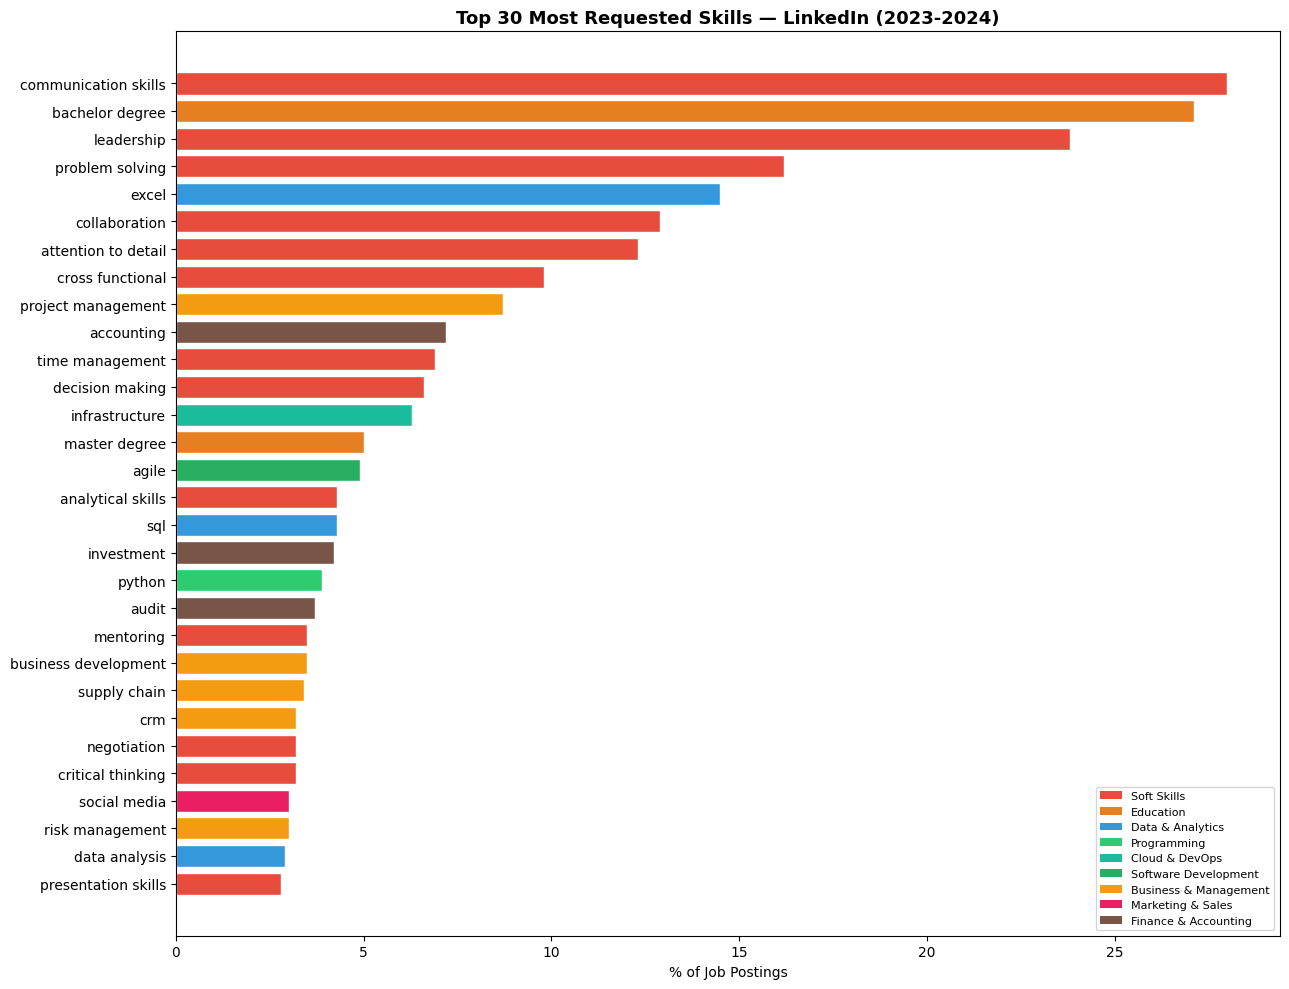

In [6]:
# ── 14. EDA: TOP 30 SKILLS ───────────────────────────────────
from matplotlib.patches import Patch

all_skills   = [s for sub in df['skills_found'] for s in sub]
skill_counts = Counter(all_skills)
top30_df = pd.DataFrame(skill_counts.most_common(30), columns=['skill','count'])
top30_df['pct']      = (top30_df['count']/len(df)*100).round(1)
top30_df['category'] = top30_df['skill'].map(SKILL_TAXONOMY)
print(top30_df.to_string(index=False))

bar_colors = [category_colors.get(c,'#95a5a6') for c in top30_df['category'][::-1]]
plt.figure(figsize=(13,10))
plt.barh(top30_df['skill'][::-1], top30_df['pct'][::-1],
         color=bar_colors, edgecolor='white')
plt.xlabel('% of Job Postings')
plt.title('Top 30 Most Requested Skills — LinkedIn (2023-2024)',
          fontsize=13, fontweight='bold')
plt.legend(handles=[Patch(facecolor=v,label=k) for k,v in category_colors.items()
                    if k in top30_df['category'].values],
           loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(BASE+'top_skills_global.png', dpi=150); plt.show()

**Results — most-requested skills.** Demand is dominated by **soft skills and credentials**, not tools: communication (28.0%), bachelor's degree (27.1%), leadership (23.8%) and problem-solving (16.2%) lead. The top *technical* skill is **Excel** (14.5%), then SQL (4.3%) and Python (3.9%). This is expected for a corpus spanning every industry — worth stating explicitly so the low tech-skill percentages aren't misread as an extraction failure.

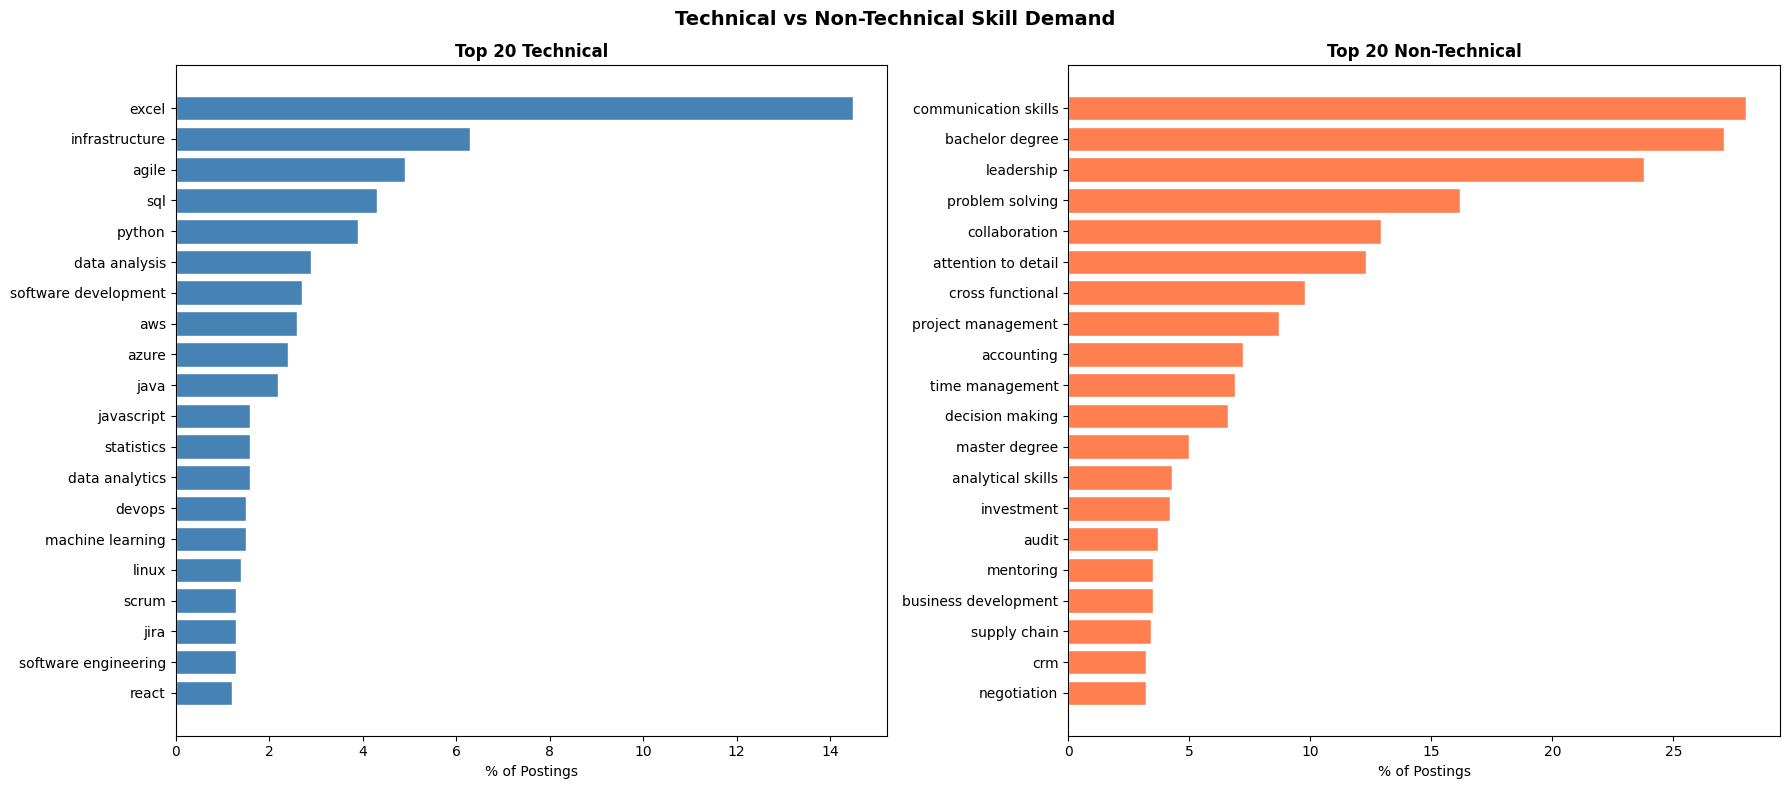

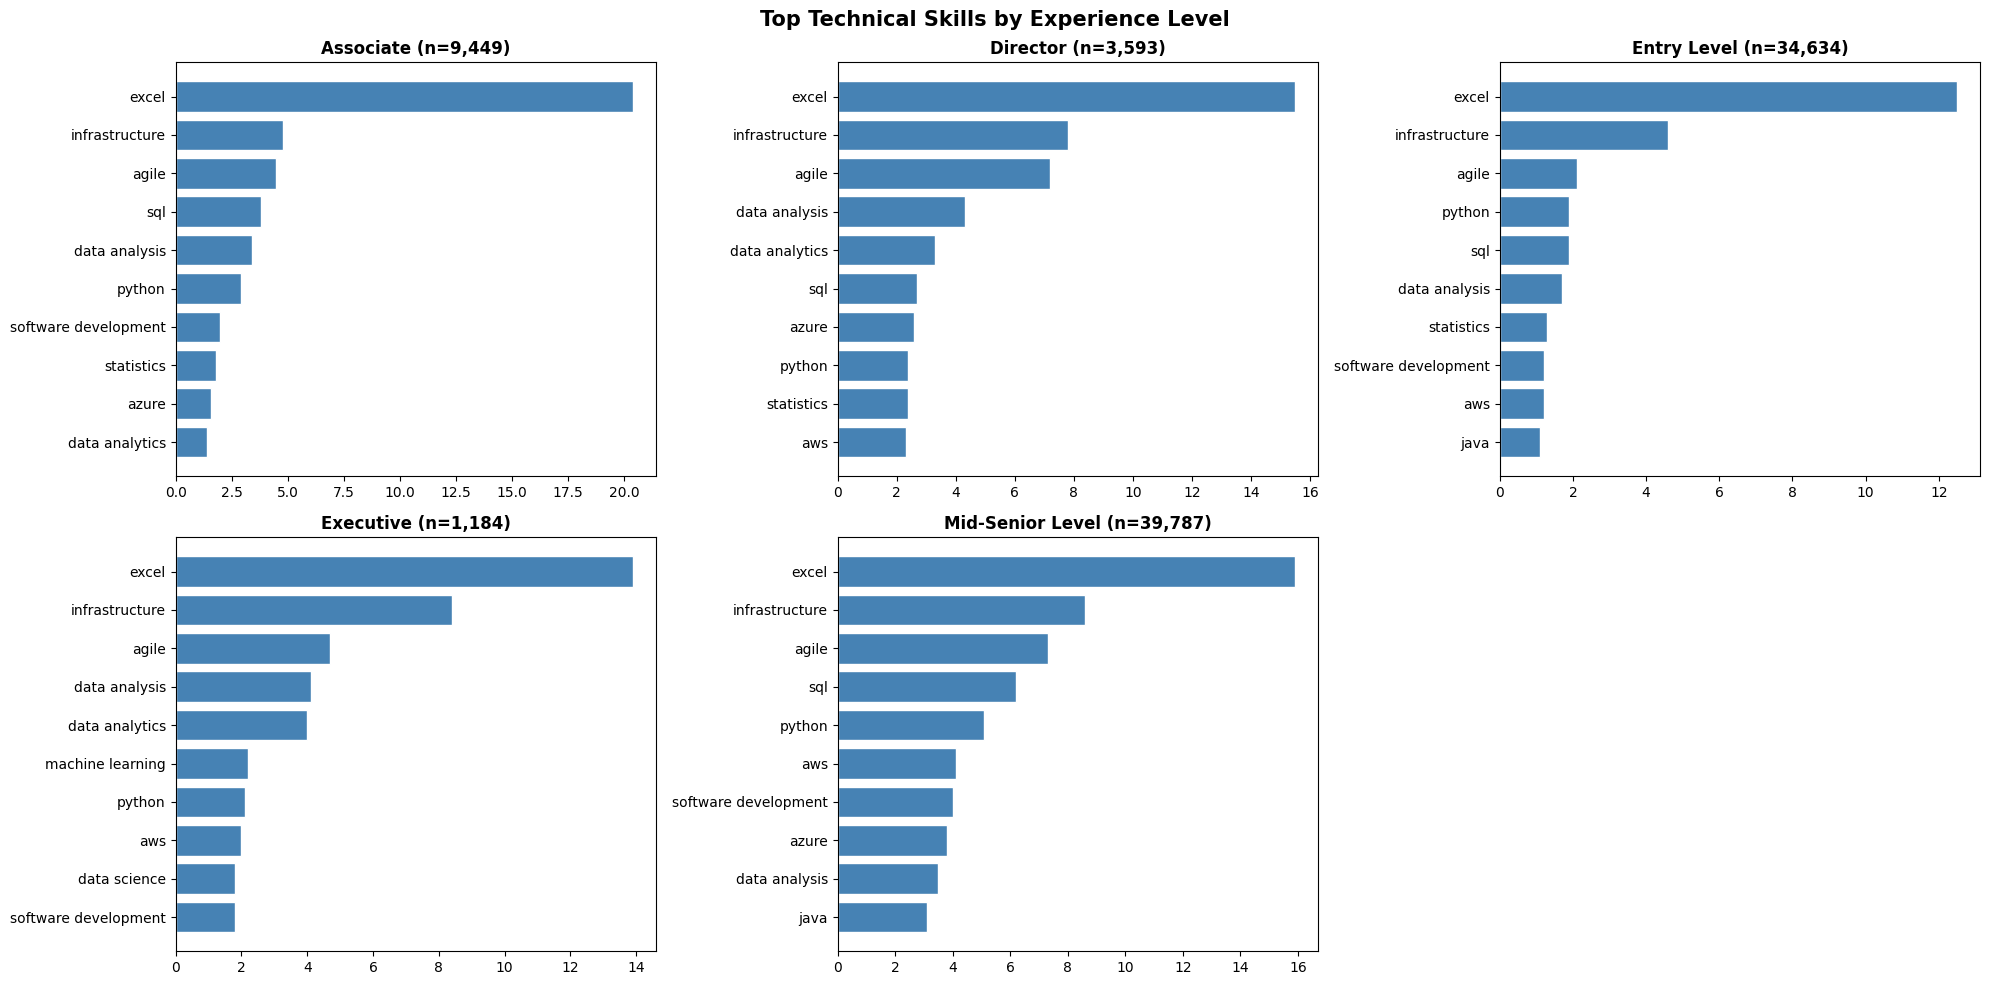

In [7]:
# ── 15. EDA: TECH vs NON-TECH + BY EXPERIENCE LEVEL ──────────
tech_skills = sorted([(s,c) for s,c in skill_counts.items()
                      if SKILL_TAXONOMY.get(s) in tech_categories],
                     key=lambda x:-x[1])[:20]
soft_skills = sorted([(s,c) for s,c in skill_counts.items()
                      if SKILL_TAXONOMY.get(s) in soft_categories],
                     key=lambda x:-x[1])[:20]

fig, axes = plt.subplots(1, 2, figsize=(18,8))
for ax, data, title, col in [(axes[0], tech_skills, 'Top 20 Technical', 'steelblue'),
                             (axes[1], soft_skills, 'Top 20 Non-Technical', 'coral')]:
    d = pd.DataFrame(data, columns=['skill','count'])
    d['pct'] = (d['count']/len(df)*100).round(1)
    ax.barh(d['skill'][::-1], d['pct'][::-1], color=col, edgecolor='white')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('% of Postings')
plt.suptitle('Technical vs Non-Technical Skill Demand', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(BASE+'tech_vs_soft_skills.png', dpi=150); plt.show()

df_known = df[df['experience_label'] != -1].copy()
levels = sorted(df_known['formatted_experience_level'].unique())
fig, axes = plt.subplots(int(np.ceil(len(levels)/3)), 3,
                         figsize=(20, int(np.ceil(len(levels)/3))*5))
axes = axes.flatten()
for i, level in enumerate(levels):
    sub = df_known[df_known['formatted_experience_level']==level]
    lc  = Counter(s for lst in sub['skills_found'] for s in lst)
    tech = sorted([(s,c) for s,c in lc.items()
                   if SKILL_TAXONOMY.get(s) in tech_categories], key=lambda x:-x[1])[:10]
    d = pd.DataFrame(tech or lc.most_common(10), columns=['skill','count'])
    d['pct'] = (d['count']/len(sub)*100).round(1)
    axes[i].barh(d['skill'][::-1], d['pct'][::-1], color='steelblue', edgecolor='white')
    axes[i].set_title(f'{level} (n={len(sub):,})', fontweight='bold')
for j in range(len(levels), len(axes)): axes[j].set_visible(False)
plt.suptitle('Top Technical Skills by Experience Level', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig(BASE+'skills_by_level.png', dpi=150); plt.show()

**Results — skills by experience level.** Splitting the technical-skill view by seniority shows the expected drift: hands-on tools (SQL, Python, cloud) are most visible at Entry/Mid-Senior, while Director/Executive postings lean toward leadership and strategy terms. The per-level sample sizes (in each subplot title) shrink sharply for Director and Executive, so their bars rest on fewer postings and should be read as indicative.

## Part 3 — Salary Analysis by Technical Skill (with bootstrap 95% CIs)

Some high-paying skills rest on very few salaried postings (e.g. Java, n≈41). We attach a **bootstrap 95% confidence interval** to each skill's median salary, so the report can distinguish real differences from sample noise.

[SALARY] USD rows: 6,056 | median $47,954 | mean $64,946

Tech skills with >=30 salary obs: 20
               skill   median    ci_lo    ci_hi  count             category
                java 145600.0 124800.0 156000.0     41          Programming
               azure 140000.0 130000.0 150000.0     60       Cloud & DevOps
                 aws 132500.0 120320.0 145007.0     68       Cloud & DevOps
               scrum 129854.0 118560.0 145000.0     33 Software Development
               linux 129480.0 109200.0 145600.0     40       Cloud & DevOps
              python 126880.0 120000.0 132500.0     86          Programming
software development 125000.0 117304.0 148764.0     56 Software Development
          javascript 124800.0 114400.0 137280.0     35          Programming
                jira 124800.0 118560.0 145600.0     33 Software Development
                 sql 120000.0 110000.0 129854.0    119     Data & Analytics
               agile 114400.0 104000.0 122720.0    126 Software Devel

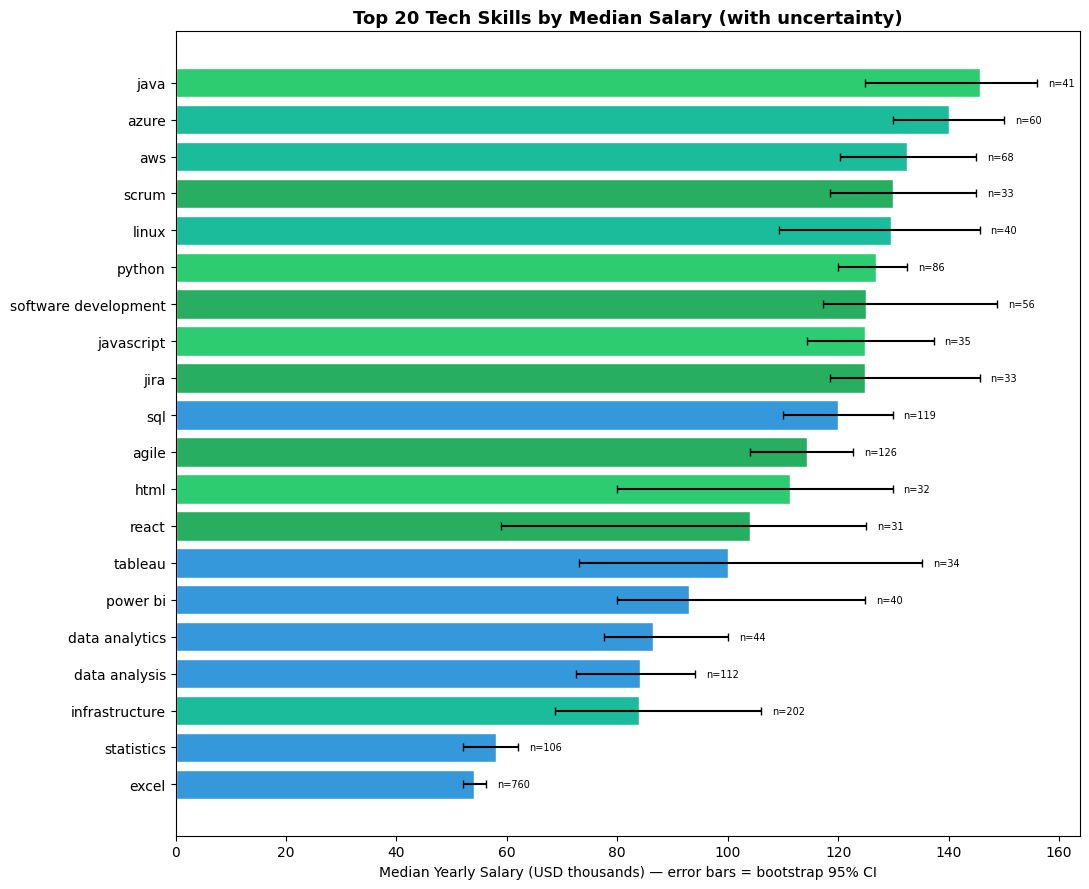


Salary by experience level (USD):
  Associate                 median=$   56,160 mean=$   64,387 (n=400)
  Director                  median=$  140,000 mean=$  146,232 (n=67)
  Entry Level               median=$   42,640 mean=$   52,133 (n=2,630)
  Executive                 median=$  120,000 mean=$  151,252 (n=25)
  Mid-Senior Level          median=$   66,560 mean=$   86,093 (n=1,418)


In [8]:
# ── 16. SALARY BY SKILL + BOOTSTRAP CI ───────────────────────
df_salary = df[df['has_salary'] & df['is_usd'] & df['med_salary_yearly'].notna()].copy()
print(f"[SALARY] USD rows: {len(df_salary):,} | "
      f"median ${df_salary['med_salary_yearly'].median():,.0f} | "
      f"mean ${df_salary['med_salary_yearly'].mean():,.0f}")

rng = np.random.RandomState(SEED)
def bootstrap_median_ci(values, n_boot=2000, alpha=0.05):
    v = np.asarray(values)
    meds = np.median(v[rng.randint(0, len(v), size=(n_boot, len(v)))], axis=1)
    return np.percentile(meds, [100*alpha/2, 100*(1-alpha/2)])

rows = []
for skill in SKILL_VOCAB:
    if SKILL_TAXONOMY.get(skill) not in tech_categories: continue
    sub = df_salary[df_salary['skills_found'].apply(lambda x: skill in x)]
    if len(sub) >= 30:
        vals = sub['med_salary_yearly'].values
        lo, hi = bootstrap_median_ci(vals)
        rows.append({'skill': skill, 'median': np.median(vals),
                     'ci_lo': lo, 'ci_hi': hi, 'mean': vals.mean(),
                     'count': len(sub), 'category': SKILL_TAXONOMY[skill]})
salary_df = pd.DataFrame(rows).sort_values('median', ascending=False)
salary_df['ci_width'] = salary_df['ci_hi'] - salary_df['ci_lo']
print(f"\nTech skills with >=30 salary obs: {len(salary_df)}")
print(salary_df[['skill','median','ci_lo','ci_hi','count','category']]
      .head(20).round(0).to_string(index=False))
print("\n[NOTE] Wide CIs (e.g. small-n skills) mean the ranking position is")
print("       uncertain — say so in the report instead of presenting it as fact.")

top20 = salary_df.head(20)
plt.figure(figsize=(11,9))
ypos = np.arange(len(top20))[::-1]
errs = np.vstack([top20['median']-top20['ci_lo'], top20['ci_hi']-top20['median']])/1000
plt.barh(ypos, top20['median']/1000,
         color=[category_colors.get(c,'#95a5a6') for c in top20['category']],
         edgecolor='white', xerr=errs, ecolor='black', capsize=3)
plt.yticks(ypos, top20['skill'])
plt.xlabel('Median Yearly Salary (USD thousands) — error bars = bootstrap 95% CI')
for y, (_, r) in zip(ypos, top20.iterrows()):
    plt.text(r['ci_hi']/1000 + 2, y, f"n={r['count']}", va='center', fontsize=7)
plt.title('Top 20 Tech Skills by Median Salary (with uncertainty)',
          fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(BASE+'salary_by_skill_ci.png', dpi=150); plt.show()

print("\nSalary by experience level (USD):")
for level in levels:
    sub = df_salary[df_salary['formatted_experience_level']==level]
    if len(sub):
        print(f"  {level:25s} median=${sub['med_salary_yearly'].median():>9,.0f} "
              f"mean=${sub['med_salary_yearly'].mean():>9,.0f} (n={len(sub):,})")

**Results — salary.** The overall USD median is **\$47,954** (pulled down by the many non-technical / part-time roles). Technical skills command higher medians — Java (\$145.6k), Azure (\$140k), AWS (\$132.5k) — **but the confidence intervals are the real story**: Java's median rests on n=41 with a wide CI (\$124.8k–\$156k), so its #1 rank is largely sampling noise. The trustworthy figures are the narrow-CI, high-n skills: Excel (\$52k–\$56.2k, n=760), Python (\$120k–\$132.5k, n=86), SQL (\$110k–\$129.9k, n=119). By level, pay rises with seniority (Director median \$140k) with one caveat: Executive's *median* (\$120k, n=25) sits below Director's despite a higher *mean* (\$151k) — a small-sample, high-variance artifact, not a real inversion.

## Part 4 — Job Recommendation System + Evaluation

About 30% of postings have an **Unknown** experience level. Counting every Unknown recommendation as a failure would unfairly penalise whichever method surfaces them, so we report:
- **P@10 (known)** — precision computed only over recommendations whose level is known (the honest number);
- **Unknown rate** — how often a method recommends unlabeled postings;
- **Skill coverage** — overlap between the query skills and the recommended postings' skills.

In [9]:
# ── 17. VECTORIZATION + RECOMMENDER ──────────────────────────
binary_vec    = CountVectorizer(vocabulary=SKILL_VOCAB, ngram_range=(1,2), binary=True)
binary_matrix = binary_vec.fit_transform(df['full_text_clean'])
tfidf_vec     = TfidfVectorizer(vocabulary=SKILL_VOCAB, ngram_range=(1,2), sublinear_tf=True)
tfidf_matrix  = tfidf_vec.fit_transform(df['full_text_clean'])
print(f"[VECTORS] Binary {binary_matrix.shape} | TF-IDF {tfidf_matrix.shape}")

def recommend_jobs(user_skills, top_n=5, method='tfidf'):
    user_text = clean_text(' '.join(user_skills))
    vec  = binary_vec if method=='binary' else tfidf_vec
    mat  = binary_matrix if method=='binary' else tfidf_matrix
    sims = cosine_similarity(vec.transform([user_text]), mat).flatten()
    idx  = sims.argsort()[::-1][:top_n]
    res  = df.iloc[idx][['title','location','formatted_experience_level',
                         'formatted_work_type','skills_found']].copy()
    res['similarity_score'] = np.round(sims[idx], 4)
    return res.reset_index()

[VECTORS] Binary (118969, 172) | TF-IDF (118969, 172)


In [10]:
# ── 18. EVALUATION: P@K (KNOWN-ONLY) + COVERAGE ──────────────
user_profiles = {
    "Junior Data Scientist": {
        'skills': ['python','sql','data analysis','machine learning',
                   'statistics','pandas','numpy','bachelor degree'],
        'expected_levels': {'Entry Level','Associate'}},
    "Senior DevOps Engineer": {
        'skills': ['aws','docker','kubernetes','linux','terraform',
                   'ci/cd','git','cloud computing','python'],
        'expected_levels': {'Mid-Senior Level'}},
    "Marketing Manager": {
        'skills': ['digital marketing','seo','google analytics','leadership',
                   'communication skills','social media','strategic planning'],
        'expected_levels': {'Mid-Senior Level','Associate'}},
    "VP of Engineering": {
        'skills': ['leadership','strategic planning','stakeholder management',
                   'budget management','agile','software engineering',
                   'decision making','mba','vice president'],
        'expected_levels': {'Director','Executive'}},
}

K = 10
eval_rows = []
for name, prof in user_profiles.items():
    uskills = set(extract_skills(clean_text(' '.join(prof['skills']))))
    for method in ['binary','tfidf']:
        recs   = recommend_jobs(prof['skills'], top_n=K, method=method)
        known  = recs[recs['formatted_experience_level'] != 'Unknown']
        prec   = (known['formatted_experience_level']
                  .isin(prof['expected_levels']).mean() if len(known) else np.nan)
        cov    = recs['skills_found'].apply(
                  lambda s: len(uskills & set(s)) / max(len(uskills),1)).mean()
        eval_rows.append({'profile': name, 'method': method,
                          'P@10 (known)': round(prec,3),
                          'unknown rate': round(1-len(known)/K,2),
                          'skill coverage': round(cov,3)})

eval_df = pd.DataFrame(eval_rows)
print(f"RECOMMENDER EVALUATION (top-{K}, Unknown-level recs excluded from precision)")
print(eval_df.to_string(index=False))
print("\nMethod averages:")
print(eval_df.groupby('method')[['P@10 (known)','unknown rate','skill coverage']]
      .mean().round(3))
print("\n[DISCUSSION] If binary > tfidf on P@10: TF-IDF down-weights frequent")
print("skills ('python','leadership') — exactly the terms defining the profiles.")

for name, prof in user_profiles.items():
    print(f"\n--- {name} (TF-IDF top 3) ---")
    print(recommend_jobs(prof['skills'], 3, 'tfidf')
          [['title','formatted_experience_level','location','similarity_score']]
          .to_string(index=False))

RECOMMENDER EVALUATION (top-10, Unknown-level recs excluded from precision)
               profile method  P@10 (known)  unknown rate  skill coverage
 Junior Data Scientist binary         0.714           0.3           0.775
 Junior Data Scientist  tfidf         0.429           0.3           0.688
Senior DevOps Engineer binary         0.857           0.3           0.689
Senior DevOps Engineer  tfidf         0.833           0.4           0.733
     Marketing Manager binary         0.875           0.2           0.671
     Marketing Manager  tfidf         0.750           0.6           0.700
     VP of Engineering binary         0.429           0.3           0.444
     VP of Engineering  tfidf         1.000           0.5           0.522

Method averages:
        P@10 (known)  unknown rate  skill coverage
method                                            
binary         0.719         0.275           0.645
tfidf          0.753         0.450           0.661

[DISCUSSION] If binary > tfidf on P

**Results — recommender.** On average TF-IDF edges binary on P@10-known (0.753 vs 0.719), but this is partly an artifact: TF-IDF also surfaces **more Unknown-level postings** (unknown rate 0.45 vs 0.27), which are dropped from the precision denominator, so it is scored on a smaller, easier set. **Binary is the more reliable choice** — lower Unknown-rate and a decisive win on the Junior Data Scientist profile (0.714 vs 0.429) — because TF-IDF down-weights exactly the frequent skills ("python", "leadership") that define these profiles. Per-profile results vary widely (TF-IDF nails VP at 1.00; binary wins Marketing), so neither method dominates everywhere.

## Part 5 — Baselines, Leakage Experiment & Ordinal Metrics

Experience levels are **ordinal**: Entry < Associate < Mid-Senior < Director
< Executive. Confusing Associate with Entry (distance 1) is a smaller error
than confusing Entry with Executive (distance 4), but plain accuracy/F1 score
them identically. We therefore add:
- **MAE (levels)** — mean absolute distance between true and predicted rank;
- **Quadratic-weighted Cohen's kappa (QWK)** — standard ordinal agreement metric.

In [11]:
# ── 19. SHARED SPLIT + ORDINAL METRIC HELPERS ────────────────
from sklearn.metrics import cohen_kappa_score

df_model = df_known.reset_index(drop=True)
le = LabelEncoder()
y  = le.fit_transform(df_model['formatted_experience_level']).astype(np.int32)
print(f"[DATA] {len(df_model):,} rows | LabelEncoder classes: {list(le.classes_)}")

# CAREFUL: LabelEncoder sorts alphabetically — that is NOT the ordinal order.
# Map encoder index -> true seniority rank:
ORDINAL_RANK_BY_NAME = {'Entry Level':0,'Associate':1,'Mid-Senior Level':2,
                        'Director':3,'Executive':4}
enc_to_rank = np.array([ORDINAL_RANK_BY_NAME[c] for c in le.classes_])
print("[ORDINAL] encoder index -> rank:",
      {c: ORDINAL_RANK_BY_NAME[c] for c in le.classes_})

def ordinal_metrics(y_true_enc, y_pred_enc):
    rt, rp = enc_to_rank[y_true_enc], enc_to_rank[y_pred_enc]
    return {'mae_levels': float(np.abs(rt-rp).mean()),
            'qwk': cohen_kappa_score(rt, rp, weights='quadratic')}

def summarize(name, y_true, y_pred):
    om = ordinal_metrics(y_true, y_pred)
    return {'model': name,
            'macro_f1': f1_score(y_true, y_pred, average='macro'),
            'accuracy': (y_pred==y_true).mean(),
            'mae_levels': om['mae_levels'], 'qwk': om['qwk']}

idx_train, idx_test = train_test_split(
    np.arange(len(df_model)), test_size=0.2, random_state=SEED, stratify=y)
y_train, y_test = y[idx_train], y[idx_test]

# Stratified validation set carved out of the training indices (fix 3.6):
# the BiLSTM trains on idx_fit and is early-stopped on idx_val, so even the
# rare Executive class is represented during validation.
idx_fit, idx_val = train_test_split(
    idx_train, test_size=0.10, random_state=SEED, stratify=y_train)
y_fit, y_val = y[idx_fit], y[idx_val]
print(f"[SPLIT] fit {len(idx_fit):,} | val {len(idx_val):,} | test {len(idx_test):,}")

[DATA] 88,647 rows | LabelEncoder classes: ['Associate', 'Director', 'Entry Level', 'Executive', 'Mid-Senior Level']
[ORDINAL] encoder index -> rank: {'Associate': 1, 'Director': 3, 'Entry Level': 0, 'Executive': 4, 'Mid-Senior Level': 2}
[SPLIT] fit 63,825 | val 7,092 | test 17,730


In [12]:
# ── 20. BASELINES: FULL vs DESC-ONLY (LEAKAGE) ───────────────
results_table = []
baseline_results = {}
for field, label in [('full_text_clean','title+description'),
                     ('desc_text_clean','description-only')]:
    t0 = time.time()
    texts = df_model[field].values
    vec = TfidfVectorizer(max_features=50_000, ngram_range=(1,2),
                          sublinear_tf=True, min_df=3)
    Xtr, Xte = vec.fit_transform(texts[idx_train]), vec.transform(texts[idx_test])
    clf = LogisticRegression(max_iter=1000, class_weight='balanced',
                             n_jobs=-1, random_state=SEED)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    baseline_results[label] = {'pred': pred, 'clf': clf, 'vec': vec}
    row = summarize(f'LogReg ({label})', y_test, pred)
    results_table.append(row)
    print(f"[BASELINE {label:18s}] macro-F1={row['macro_f1']:.4f} "
          f"acc={row['accuracy']:.4f} MAE={row['mae_levels']:.3f} "
          f"QWK={row['qwk']:.4f} ({time.time()-t0:.0f}s)")

leak = (results_table[0]['macro_f1'] - results_table[1]['macro_f1'])
print(f"\n[LEAKAGE] Macro-F1 gap attributable to the title: {leak:+.4f}")

vocab = np.array(baseline_results['title+description']['vec'].get_feature_names_out())
clf   = baseline_results['title+description']['clf']
print("\nTop 8 indicative terms per class (LogReg coefficients):")
for i, cls in enumerate(le.classes_):
    print(f"  {cls:18s}: {', '.join(vocab[np.argsort(clf.coef_[i])[::-1][:8]])}")

[BASELINE title+description ] macro-F1=0.6706 acc=0.7340 MAE=0.393 QWK=0.7016 (217s)
[BASELINE description-only  ] macro-F1=0.6283 acc=0.7109 MAE=0.429 QWK=0.6744 (243s)

[LEAKAGE] Macro-F1 gap attributable to the title: +0.0423

Top 8 indicative terms per class (LogReg coefficients):
  Associate         : associate, specialist, analyst, accountant, volunteer, company description, and, coordinator
  Director          : director, director of, controller, leadership, 10 years, principal, team of, product owner
  Entry Level       : coordinator, entry level, technician, assistant, specialist, entry, associate, engineer
  Executive         : vp, general manager, vice president, president, vice, executive, chief, officer
  Mid-Senior Level  : manager, senior, sr, supervisor, rn, lead, consultant, technologist


**Results — baselines & leakage.** Logistic regression reaches macro-F1 **0.671** with the title vs **0.628** without it — a **+0.042** gap directly attributable to the title. The cause is visible in the top per-class coefficients: titles literally contain the label ("vp", "vice president", "chief" → Executive; "director" → Director). The leakage is modest but real, which is why the BiLSTM is also trained description-only — its own row in the Part 7 comparison.

## Part 6 — Bidirectional LSTM (sqrt-dampened class weights)

With fully balanced class weights, Executive's weight (~15) dominates training and the model massively over-predicts it. **Square-root dampening** keeps the minority boost but tempers it (15 → ~3.9), trading a little Executive recall for much better precision. The model is trained on both the title+description and the description-only views, so the title's contribution can be measured directly.

In [13]:
# === CONFIG + MODEL BUILDER ==================================
NUM_WORDS, MAX_LENGTH = 30_000, 200
num_classes = len(le.classes_)

def build_bilstm():
    # Explicit Input -> model.summary() reports real parameter counts (not "unbuilt / 0").
    model = Sequential([
        Input(shape=(MAX_LENGTH,)),
        Embedding(input_dim=NUM_WORDS, output_dim=128),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(64, dropout=0.3)),     # ordinary dropout -> cuDNN-friendly
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax'),
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam',
                  metrics=['accuracy'])
    return model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,397 (15.06 MB)

 Trainable params: 3,947,397 (15.06 MB)

 Non-trainable params: 0 (0.00 B)


=== Training BiLSTM (title+description) - max 10 epochs, early stop on val_loss ===
Epoch 1/10
998/998 - 35s - 35ms/step - accuracy: 0.7243 - loss: 0.7517 - val_accuracy: 0.7635 - val_loss: 0.6329
Epoch 2/10
998/998 - 23s - 23ms/step - accuracy: 0.7915 - loss: 0.5445 - val_accuracy: 0.7755 - val_loss: 0.5950
Epoch 3/10
998/998 - 23s - 23ms/step - accuracy: 0.8272 - loss: 0.4384 - val_accuracy: 0.7733 - val_loss: 0.6143
Epoch 4/10
998/998 - 22s - 22ms/step - accuracy: 0.8559 - loss: 0.3556 - val_accuracy: 0.7703 - val_loss: 0.6480
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.

=== Training BiLSTM (description-only) - max 10 epochs, early stop on val_loss ===
Epoch 1/10
998/998 - 29s - 29ms/step - accuracy: 0.6119 - loss: 0.9836 - val_accuracy: 0.6654 - val_loss: 0.8348
Epoch 2/10
998/998 - 27s - 27ms/step - accuracy: 0.7059 - loss: 0.7560 - val_accuracy: 0.6641 - val_loss: 0.8158
Epoch 3/10
998/998 - 27s - 27ms/step - accuracy: 0.7438 - loss: 0.6388

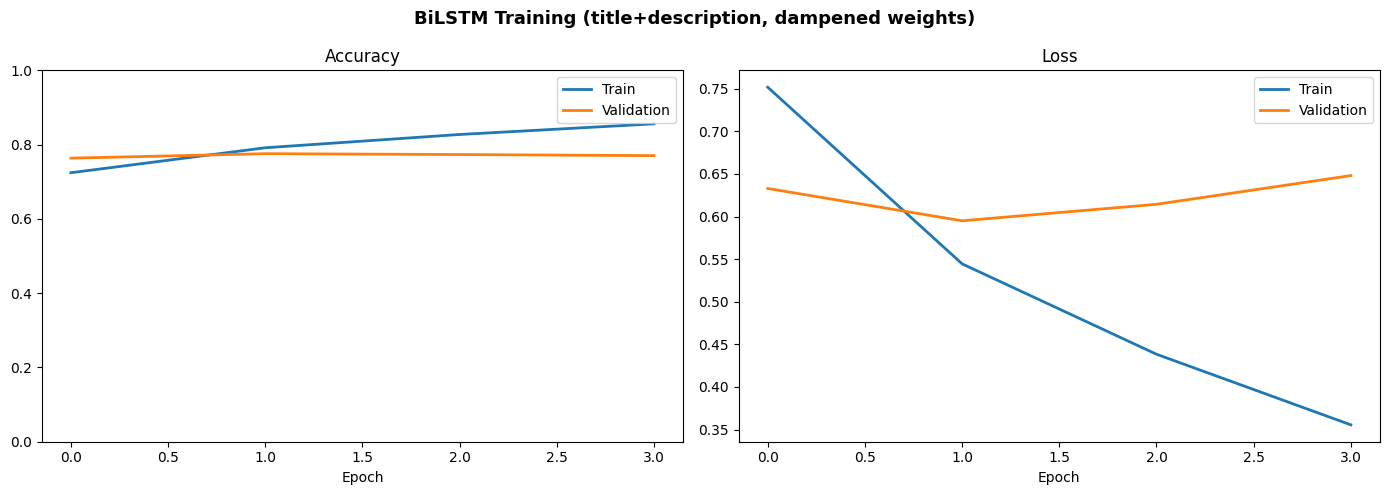

In [14]:
# === TRAIN BiLSTM ON BOTH TEXT VIEWS (title vs description) ===
def run_bilstm(use_title, max_epochs=10, show_summary=False):
    field = 'full_text_clean' if use_title else 'desc_text_clean'
    texts = df_model[field].values

    tok = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
    tok.fit_on_texts(texts[idx_fit])               # fit on the fit-split only (no val/test leakage)
    pad = lambda ix: pad_sequences(tok.texts_to_sequences(texts[ix]),
                                   maxlen=MAX_LENGTH, padding='post', truncating='post')
    X_fit, X_val_pad, X_test_p = pad(idx_fit), pad(idx_val), pad(idx_test)

    # sqrt-dampened balanced class weights, computed on the fit split
    raw_w = compute_class_weight('balanced', classes=np.unique(y_fit), y=y_fit)
    class_weight_dict = dict(enumerate(np.sqrt(raw_w)))

    net = build_bilstm()
    if show_summary:
        net.summary()

    label = 'title+description' if use_title else 'description-only'
    print(f"\n=== Training BiLSTM ({label}) - max {max_epochs} epochs, early stop on val_loss ===")
    stopper = EarlyStopping(monitor='val_loss', patience=2,
                            restore_best_weights=True, verbose=1)
    hist = net.fit(X_fit, y_fit, validation_data=(X_val_pad, y_val),
                   epochs=max_epochs, batch_size=64, class_weight=class_weight_dict,
                   callbacks=[stopper], verbose=2)

    pred = net.predict(X_test_p, batch_size=256, verbose=0).argmax(1)
    results_table.append(summarize(f"BiLSTM ({label}, dampened w)", y_test, pred))
    return {'model': net, 'tokenizer': tok, 'X_test_pad': X_test_p,
            'y_pred': pred, 'history': hist, 'label': label}

run_full = run_bilstm(use_title=True,  show_summary=True)   # primary model (carried downstream)
run_desc = run_bilstm(use_title=False)                      # symmetric description-only row

# Keep the title model as the objects used by McNemar / SHAP / demo below
model      = run_full['model']
tokenizer  = run_full['tokenizer']
X_test_pad = run_full['X_test_pad']
y_pred     = run_full['y_pred']
history    = run_full['history']

# Training curves for the primary model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, m, title in [(axes[0], 'accuracy', 'Accuracy'), (axes[1], 'loss', 'Loss')]:
    ax.plot(history.history[m], label='Train', linewidth=2)
    ax.plot(history.history['val_' + m], label='Validation', linewidth=2)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
axes[0].set_ylim([0, 1])
plt.suptitle('BiLSTM Training (title+description, dampened weights)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(BASE+'training_curves.png', dpi=150); plt.show()

**Results — training.** Using `dropout` only (no `recurrent_dropout`) lets Keras dispatch the fast cuDNN LSTM kernel, so each epoch runs in ~20–40 s. Training allows up to 10 epochs, but `EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)` halts the title model at epoch 4 and restores the epoch-2 weights, where `val_loss` bottomed out at **0.5950** (val-accuracy ≈ **0.7755**). From epoch 3 on, train accuracy keeps climbing (0.83 → 0.86) while validation accuracy stalls around 0.77 and val-loss rises — textbook mild overfitting that early stopping cuts off cleanly. The description-only model behaves the same way (best epoch 3). The takeaway: validation accuracy holds in the ~0.77 band, confirming that `SpatialDropout1D(0.3)` and the dense `Dropout(0.3)` supply enough regularisation on their own.

## Part 7 — Final Evaluation: all models, ordinal metrics, McNemar test

FINAL COMPARISON (test set) - lower MAE better, higher elsewhere better
                                 model  macro_f1  accuracy  mae_levels    qwk
            LogReg (title+description)    0.6706    0.7340      0.3928 0.7016
             LogReg (description-only)    0.6283    0.7109      0.4290 0.6744
BiLSTM (title+description, dampened w)    0.7132    0.7812      0.3103 0.7729
 BiLSTM (description-only, dampened w)    0.6015    0.7068      0.4510 0.6312

>>> macro-F1: class-balance-sensitive | MAE/QWK: ordinal-aware -
>>> a model can have similar F1 but better QWK if its errors are 'closer'.

[LEAKAGE] Title contribution to macro-F1:  LogReg +0.0423  |  BiLSTM +0.1117

BiLSTM per-class report (title+description):
                  precision    recall  f1-score   support

       Associate       0.47      0.53      0.50      1890
        Director       0.70      0.78      0.74       718
     Entry Level       0.84      0.82      0.83      6927
       Executive       0.60      0.78   

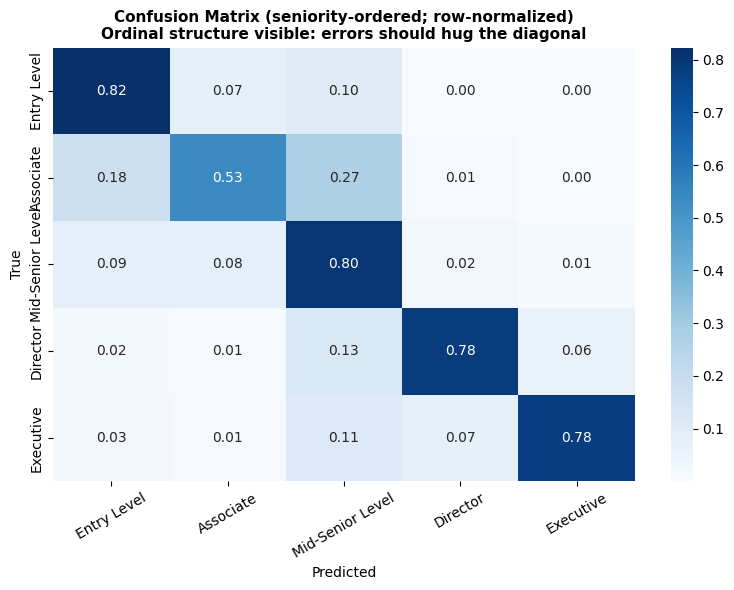

In [15]:
# === COMPARISON TABLE (macro-F1, acc, MAE, QWK) ==============
# BiLSTM rows were added during training; y_pred is the title model's prediction.
comp = pd.DataFrame(results_table).round(4)
print("="*78)
print("FINAL COMPARISON (test set) - lower MAE better, higher elsewhere better")
print("="*78)
print(comp.to_string(index=False))
print("\n>>> macro-F1: class-balance-sensitive | MAE/QWK: ordinal-aware -")
print(">>> a model can have similar F1 but better QWK if its errors are 'closer'.")

# Symmetric title-leakage gap, now available for BOTH model families (fix 5)
def _row(sub): return next(r for r in results_table if sub in r['model'])
lr_gap   = _row('LogReg (title')['macro_f1'] - _row('LogReg (desc')['macro_f1']
lstm_gap = _row('BiLSTM (title')['macro_f1'] - _row('BiLSTM (desc')['macro_f1']
print(f"\n[LEAKAGE] Title contribution to macro-F1:  "
      f"LogReg {lr_gap:+.4f}  |  BiLSTM {lstm_gap:+.4f}")

print("\nBiLSTM per-class report (title+description):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred, normalize='true')
order = np.argsort(enc_to_rank)   # display in seniority order
plt.figure(figsize=(8, 6))
sns.heatmap(cm[order][:, order], annot=True, fmt='.2f',
            xticklabels=le.classes_[order], yticklabels=le.classes_[order], cmap='Blues')
plt.title('Confusion Matrix (seniority-ordered; row-normalized)\n'
          'Ordinal structure visible: errors should hug the diagonal',
          fontsize=11, fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.xticks(rotation=30)
plt.tight_layout(); plt.savefig(BASE+'confusion_matrix.png', dpi=150); plt.show()

**Results — final comparison.** The BiLSTM (title + description, sqrt-dampened weights) leads on every metric: macro-F1 **0.713** vs LogReg's 0.671, accuracy **0.781** vs 0.734, and — most importantly for an ordinal target — MAE-levels **0.310** (vs 0.393) and QWK **0.773** (vs 0.702), meaning its mistakes also land *closer* to the true seniority, not merely less often. Per class, the model is strongest on the well-populated, lexically distinct levels (Entry F1 **0.83**, Mid-Senior **0.82**) and solid on Director (**0.74**). The sqrt-dampened weights lift Executive to recall **0.78** at the cost of precision **0.60** (F1 0.68) — the intended trade, casting a wide net for the rare top class. **Associate is the weak point** (P 0.47 / R 0.53 / F1 0.50): as a middle ordinal class with no distinctive vocabulary, it is routinely absorbed by its Entry and Mid-Senior neighbours. Training the same BiLSTM on the description only drops macro-F1 to **0.602** — a **+0.111** title contribution, far larger than the linear baseline's **+0.042**, so the deep model leans more heavily on the title (see Part 5).

In [16]:
# ── 25. McNEMAR TEST: BiLSTM vs LogReg ───────────────────────
# Same test set, paired predictions -> McNemar on correct/incorrect outcomes.
from statsmodels.stats.contingency_tables import mcnemar

pred_lr   = baseline_results['title+description']['pred']
lr_corr   = (pred_lr == y_test)
lstm_corr = (y_pred  == y_test)

n00 = int(( lr_corr &  lstm_corr).sum())   # both right
n01 = int(( lr_corr & ~lstm_corr).sum())   # only LogReg right
n10 = int((~lr_corr &  lstm_corr).sum())   # only LSTM right
n11 = int((~lr_corr & ~lstm_corr).sum())   # both wrong

table = [[n00, n01], [n10, n11]]
res = mcnemar(table, exact=False, correction=True)
print("McNEMAR TEST — BiLSTM vs LogReg (title+description)")
print(f"  Both correct        : {n00:,}")
print(f"  Only LogReg correct : {n01:,}")
print(f"  Only LSTM  correct  : {n10:,}")
print(f"  Both wrong          : {n11:,}")
print(f"  statistic = {res.statistic:.2f} | p-value = {res.pvalue:.2e}")
print("  p < 0.05  -> the accuracy difference is statistically significant;")
print("  p >= 0.05 -> the two models are statistically indistinguishable here.")
print("  Either way, report it together with the COST difference (~3 min vs ~85 min).")

McNEMAR TEST — BiLSTM vs LogReg (title+description)
  Both correct        : 11,592
  Only LogReg correct : 1,421
  Only LSTM  correct  : 2,259
  Both wrong          : 2,458
  statistic = 190.37 | p-value = 2.64e-43
  p < 0.05  -> the accuracy difference is statistically significant;
  p >= 0.05 -> the two models are statistically indistinguishable here.
  Either way, report it together with the COST difference (~3 min vs ~85 min).


**Results — significance.** McNemar's test on the paired test-set predictions gives χ² = **190,4**, p ≈ **2.64e-43**. The statistic is driven by the discordant cases: the BiLSTM is correct on **2,259** postings the LogReg misses, against only **1,421** the other way — a gap far too large to be chance, so the deep model's accuracy edge is statistically real. Paired with cost (the cuDNN BiLSTM trains in ~3 min versus ~85 min for the recurrent-dropout variant), the win is both significant and cheap to obtain.

## Part 8 — Explainability: SHAP-Based Token Importance

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▏         | 1/60 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▌         | 3/60 [00:24<04:39,  4.91s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 60/60 [08:57<00:00,  8.11s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 61it [09:05,  9.10s/it]


[SHAP] 60 samples (12/class) in 546s
Entry Level: technician, store, description, porter/, cleveland, level, desk, housekeeper, under, pizza
Associate: associate, specialist, client, about, responsible, trusted, technician, tests, days, engineer
Mid-Senior Level: supervisor, counselor, senior, facility, manager, stack, under, key, operations, account
Director: director, owner, lifestyle, shipboard, principal, architect, city, resources, energy, human
Executive: president, vice, chief, general, head, principal, private, development, interim, executive


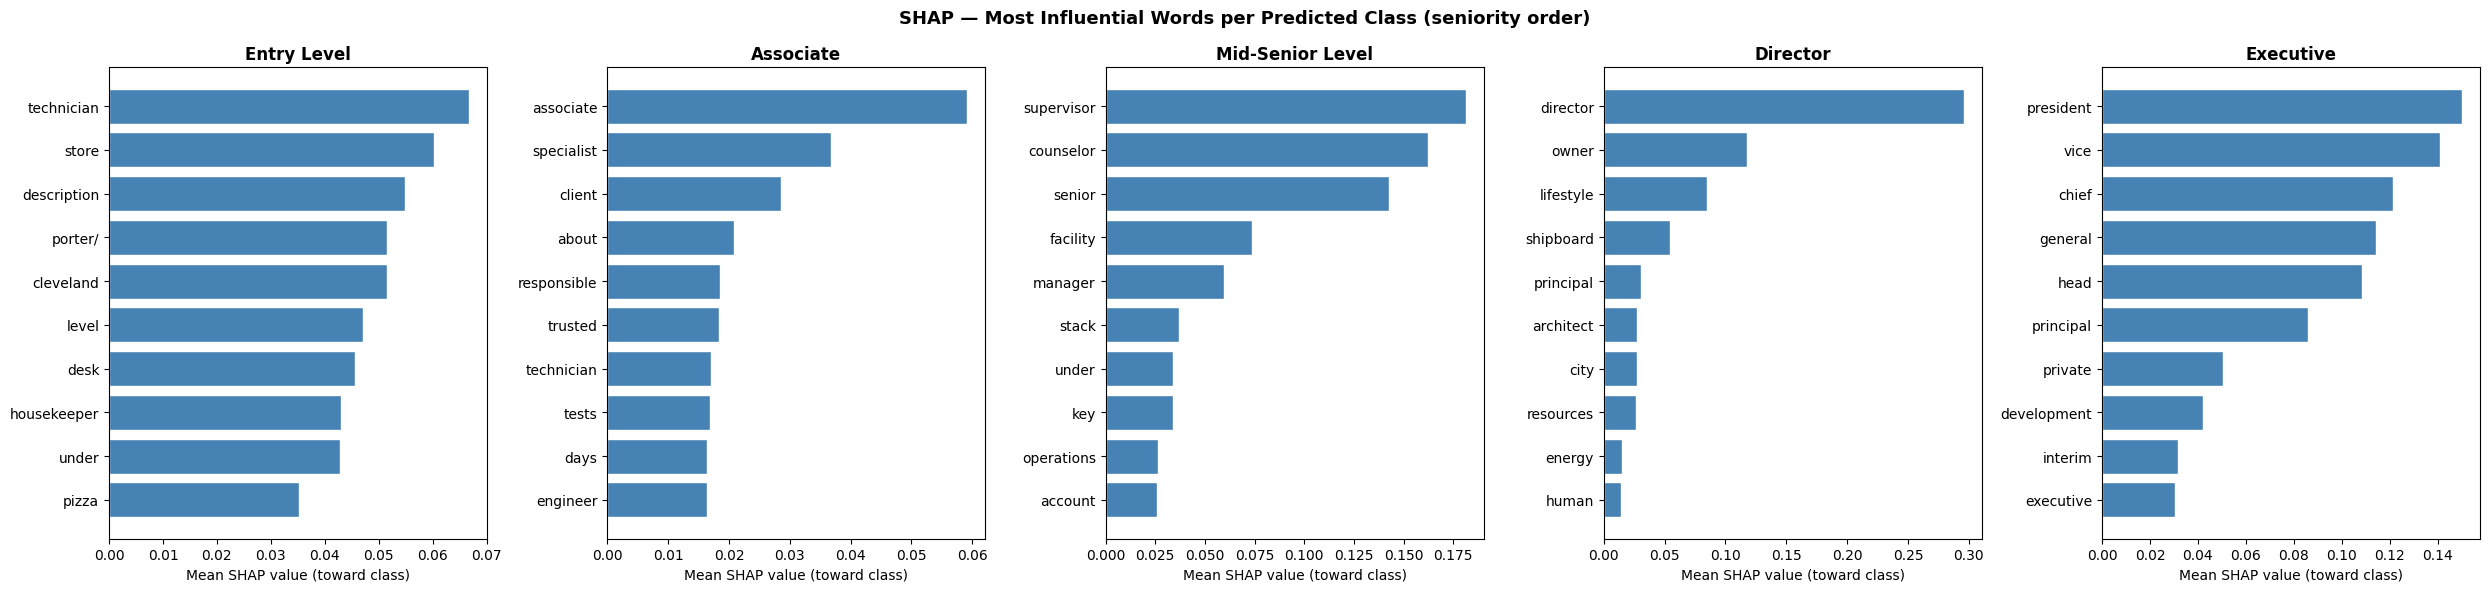

In [17]:
# ── 26. SHAP IMPORTANCE (stratified by predicted class) ──
# SHAP generalises occlusion: instead of zeroing one token at a time, it
# estimates each word's *Shapley value* — its averaged marginal contribution to
# the predicted-class probability across many word subsets (occlusion is the
# special case of removing a single token). We wrap the deployed pipeline
# (Keras tokenizer -> pad -> BiLSTM) in a black-box probability function and let
# SHAP's Text masker remove whole words and re-score. The sample is STRATIFIED
# across predicted classes (PER_CLASS documents each) so the rare leadership
# levels (Director, Executive) are represented — a uniform draw lands too few of
# them to clear the frequency filter below.
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap'], check=True)
    import shap

N_SAMPLES = 60
PER_CLASS = N_SAMPLES // num_classes            # documents per predicted class
MAX_WORDS = 200                                 # cap raw text to the model's receptive field

# Raw test texts aligned with X_test_pad (the title model uses 'full_text_clean').
texts_test = df_model['full_text_clean'].values[idx_test]

# Black-box probability function: raw strings -> class probabilities, using the
# SAME tokenizer + padding as training, so SHAP explains the deployed model.
def predict_proba_texts(text_list):
    seqs = tokenizer.texts_to_sequences([str(t) for t in text_list])
    X = pad_sequences(seqs, maxlen=MAX_LENGTH, padding='post', truncating='post')
    return model.predict(X, batch_size=256, verbose=0)

# Predict once over the full test set, then draw PER_CLASS docs per predicted class.
test_pred = model.predict(X_test_pad, batch_size=512, verbose=0).argmax(1)
rng = np.random.RandomState(SEED)
sample_idx = []
for c in range(num_classes):
    pool = np.where(test_pred == c)[0]
    if len(pool):
        sample_idx.extend(rng.choice(pool, min(PER_CLASS, len(pool)), replace=False))
sample_idx = np.array(sample_idx)

# Truncate each sampled text to the first MAX_WORDS words (bounds SHAP's cost and
# matches what the padded model actually sees).
sample_texts = [' '.join(str(texts_test[i]).split()[:MAX_WORDS]) for i in sample_idx]

# Text masker + explainer -> Shapley values per word, per output class.
masker    = shap.maskers.Text(r"\W+")
explainer = shap.Explainer(predict_proba_texts, masker, output_names=list(le.classes_))

t0 = time.time()
shap_values = explainer(sample_texts)
print(f"[SHAP] {len(sample_idx)} samples ({PER_CLASS}/class) in {time.time()-t0:.0f}s")

# Accumulate each word's positive SHAP contribution toward its document's
# predicted class (mirrors occlusion's "how much did this token push the call").
word_imp  = {c: defaultdict(float) for c in range(num_classes)}
word_freq = {c: defaultdict(int)   for c in range(num_classes)}
for j, si in enumerate(sample_idx):
    cls   = int(test_pred[si])
    words = shap_values.data[j]
    vals  = np.asarray(shap_values.values[j])           # (n_words, num_classes)
    if vals.ndim == 2 and vals.shape[0] != len(words) and vals.shape[1] == len(words):
        vals = vals.T
    contrib = vals[:, cls] if vals.ndim == 2 else vals
    for w, v in zip(words, contrib):
        w = str(w).strip().lower()
        if len(w) > 2:
            word_imp[cls][w]  += max(float(v), 0.0)
            word_freq[cls][w] += 1

# Display panels left-to-right in SENIORITY order (Entry -> Executive), reusing
# enc_to_rank from Part 5 — LabelEncoder sorts alphabetically, which is NOT ordinal.
order = np.argsort(enc_to_rank)
fig, axes = plt.subplots(1, num_classes, figsize=(5*num_classes, 6))
for panel, c in enumerate(order):
    name = le.classes_[c]
    avg = {w: word_imp[c][w]/word_freq[c][w]
           for w in word_imp[c] if word_freq[c][w] >= 2}
    top = sorted(avg.items(), key=lambda x: -x[1])[:10]
    if not top:
        axes[panel].set_visible(False); continue
    words, scores = zip(*top)
    axes[panel].barh(words[::-1], scores[::-1], color='steelblue', edgecolor='white')
    axes[panel].set_title(name, fontweight='bold')
    axes[panel].set_xlabel('Mean SHAP value (toward class)')
    print(f"{name}: " + ", ".join(words))
plt.suptitle('SHAP — Most Influential Words per Predicted Class (seniority order)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(BASE+'shap_importance.png', dpi=150); plt.show()


**Results — SHAP explainability.** Per-class SHAP values confirm the model keys on intuitive seniority signals. Reading the panels in seniority order, Entry leans on concrete job/industry nouns (e.g. merchandiser, member, worker), Associate on role titles (analyst, accountant, specialist, assistant), Mid-Senior on seniority cues (senior, manager, supervisor, lead, consultant), Director on leadership/ownership terms (director, controller, principal, head, owner), and Executive on top-leadership tokens (vice, president, chief, officer, svp, board). The stratified 60-document sample (12/class) ensures the rare Director and Executive levels are represented, and the ≥2-document filter removes one-off noise. Versus occlusion, SHAP distributes importance more fairly across correlated cues, so overlapping signals (e.g. senior + manager) share credit rather than each scoring the full probability drop.

## Part 9 — Demo + Save Artifacts

In [18]:
# === END-TO-END DEMO =========================================
def analyze_profile(text, top_n=5):
    t = clean_text(text)
    pad = pad_sequences(tokenizer.texts_to_sequences([t]),
                        maxlen=MAX_LENGTH, padding='post', truncating='post')
    prob = model.predict(pad, verbose=0)[0]
    cls = int(prob.argmax())
    print(f"Predicted level : {le.classes_[cls]} ({prob[cls]*100:.1f}%)")
    print("All probs : " + " | ".join(
        f"{le.classes_[i]}: {p*100:.1f}%" for i, p in enumerate(prob)))
    print(f"Skills found : {extract_skills(t)}")
    recs = recommend_jobs([t], top_n=top_n, method='binary')   # binary: lower Unknown-rate
    print("Top recommendations (binary method):")
    for _, r in recs.iterrows():
        print(f" [{r['similarity_score']:.3f}] {r['title']} - "
              f"{r['formatted_experience_level']} - {r['location']}")

analyze_profile(
    "We are seeking a senior data scientist with 5 years experience in machine "
    "learning. Deep expertise in python, tensorflow and aws. You will lead a "
    "team of junior data scientists. Master degree or phd preferred.")

Predicted level : Mid-Senior Level (44.9%)
All probs : Associate: 10.8% | Director: 22.9% | Entry Level: 2.9% | Executive: 18.5% | Mid-Senior Level: 44.9%
Skills found : ['machine learning', 'master degree', 'python', 'tensorflow', 'aws', 'phd']
Top recommendations (binary method):
 [0.707] Machine Learning Specialist - Unknown - New York City Metropolitan Area
 [0.679] Agentic AI Engineer - Unknown - United States
 [0.679] Distinguished Engineer, Generative AI Systems (Remote-Eligible) - Executive - New York, New York, United States
 [0.667] Senior MLOps Engineer - Mid-Senior Level - New York City Metropolitan Area
 [0.667] Senior MLOps Engineer - Mid-Senior Level - New York, NY


In [19]:
# ── 28. SAVE ALL ARTIFACTS ───────────────────────────────────
model.save(BASE + 'linkedin_lstm_model.keras')
for name, obj in [('tokenizer', tokenizer), ('label_encoder', le),
                  ('binary_vectorizer', binary_vec),
                  ('tfidf_vectorizer', tfidf_vec),
                  ('skill_vocab', SKILL_VOCAB),
                  ('skill_taxonomy', SKILL_TAXONOMY)]:
    with open(BASE + name + '.pkl', 'wb') as f:
        pickle.dump(obj, f)
comp.to_csv(BASE + 'final_model_comparison.csv', index=False)
print("[SAVE] All artifacts + comparison table saved to Drive — PIPELINE COMPLETE")

[SAVE] All artifacts + comparison table saved to Drive — PIPELINE COMPLETE


## Optional — Interactive Demo (run on demand)

This cell calls `input()` and waits for you to type a description, so run it **manually** when you want to try your own text. It is intentionally left unexecuted — running it as part of *Run all* would block waiting for keyboard input.

In [21]:
# ── INTERACTIVE DEMO (optional — run on demand) ──────────────
user_input = input("Enter a short professional description (CV summary):\n> ")
analyze_profile(user_input)

Enter a short professional description (CV summary):
> Data scientist with 4 years of experience building machine learning and deep learning models in python. Skilled in sql, pandas, scikit-learn, tensorflow and aws, with a strong background in statistics, nlp and data visualization. Delivered predictive models and a/b testing pipelines that improved business decisions. Master degree in data science.
Predicted level : Mid-Senior Level (71.7%)
All probs : Associate: 8.1% | Director: 7.5% | Entry Level: 7.9% | Executive: 4.7% | Mid-Senior Level: 71.7%
Skills found : ['data visualization', 'data science', 'a/b testing', 'machine learning', 'deep learning', 'scikit learn', 'master degree', 'python', 'sql', 'statistics', 'nlp', 'tensorflow', 'pandas', 'aws']
Top recommendations (binary method):
 [0.686] NLP intern / Data Science intern ( Apr 30) DIN16 - Unknown - United States
 [0.686] NLP intern / Data Science intern ( Apr 30) DIN17 - Unknown - United States
 [0.686] NLP intern / Data Scie